# DeepGlobe Land Cover Classification Pipeline
This notebook implements a semantic segmentation pipeline using PyTorch for U-Net, DeepLabV3+, and SegFormer.

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balraj98/deepglobe-land-cover-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'deepglobe-land-cover-classification-dataset' dataset.
Path to dataset files: /kaggle/input/deepglobe-land-cover-classification-dataset


In [10]:
# 1. Setup and Dependencies
!pip install -q albumentations segmentation-models-pytorch transformers

import os
import random
import time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

import albumentations as A
from albumentations.pytorch import ToTensorV2

from google.colab import drive
# Fixed: Check if drive is already mounted to avoid ValueError
if not os.path.exists('/content/drive/MyDrive'):
    try:
        drive.mount('/content/drive')
    except Exception as e:
        print(f"Drive mount skipped or failed: {e}")
else:
    print("Drive already mounted.")

# Reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

Drive already mounted.


In [11]:
import torch
import os

class Config:
    IMAGE_SIZE = 256
    BATCH_SIZE = 16
    EPOCHS = 2
    LR = 1e-3
    NUM_WORKERS = 2
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    DRIVE_PATH = '/content/drive/MyDrive/deepglobe_project'
    # Fixed: Use DRIVE_PATH directly instead of Config.DRIVE_PATH inside the class definition
    CHECKPOINT_DIR = os.path.join(DRIVE_PATH, 'checkpoints')
    LOG_DIR = os.path.join(DRIVE_PATH, 'logs')

os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(Config.LOG_DIR, exist_ok=True)

print(f"Using device: {Config.DEVICE}")

Using device: cuda


In [12]:
# 3. Dataset and Transforms
# DeepGlobe class mapping (RGB to Class Index)
class_map = {
    (0, 255, 255): 0,   # Urban
    (255, 255, 0): 1,   # Agriculture
    (255, 0, 255): 2,   # Rangeland
    (0, 255, 0): 3,     # Forest
    (0, 0, 255): 4,     # Water
    (255, 255, 255): 5, # Barren
    (0, 0, 0): 6        # Unknown
}

def rgb_to_mask(rgb_mask, class_map):
    mask = np.zeros(rgb_mask.shape[:2], dtype=np.uint8)
    for rgb, idx in class_map.items():
        mask[(rgb_mask == rgb).all(axis=-1)] = idx
    return mask

class DeepGlobeDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        mask_path = self.df.iloc[idx]['mask_path']

        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.cvtColor(cv2.imread(mask_path), cv2.COLOR_BGR2RGB)
        mask = rgb_to_mask(mask, class_map)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask.long()

train_transform = A.Compose([
    A.RandomCrop(Config.IMAGE_SIZE, Config.IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=45, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(Config.IMAGE_SIZE, Config.IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [23]:
import segmentation_models_pytorch as smp
from transformers import SegformerForSemanticSegmentation

def get_model(model_name, num_classes=7):
    if model_name == "unet":
        model = smp.Unet(encoder_name="resnet50", encoder_weights="imagenet", in_channels=3, classes=num_classes)
        for param in model.encoder.parameters():
            param.requires_grad = False
        return model
    elif model_name == "deeplabv3plus":
        model = smp.DeepLabV3Plus(encoder_name="resnet50", encoder_weights="imagenet", in_channels=3, classes=num_classes)
        for param in model.encoder.parameters():
            param.requires_grad = False
        return model
    elif model_name == "segformer":
        model = SegformerForSemanticSegmentation.from_pretrained(
            "nvidia/mit-b2",
            num_labels=num_classes,
            ignore_mismatched_sizes=True
        )
        # Fixed: SegFormer uses .segformer instead of .encoder
        if hasattr(model, 'segformer'):
            for param in model.segformer.parameters():
                param.requires_grad = False
        return model
    else:
        raise ValueError("Invalid model name")

In [14]:
# 5. Loss and Metrics
class CombinedLoss(nn.Module):
    def __init__(self, dice_weight=0.5):
        super(CombinedLoss, self).__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = smp.losses.DiceLoss(mode='multiclass')
        self.dice_weight = dice_weight

    def forward(self, pred, target):
        return (1 - self.dice_weight) * self.ce(pred, target) + self.dice_weight * self.dice(pred, target)

def calculate_metrics(pred, target, num_classes=7):
    # pred: (B, C, H, W), target: (B, H, W)
    pred_labels = torch.argmax(pred, dim=1)

    # Use SMP functional metrics
    tp, fp, fn, tn = smp.metrics.get_stats(pred_labels, target, mode='multiclass', num_classes=num_classes)

    iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="macro")
    f1 = smp.metrics.f1_score(tp, fp, fn, tn, reduction="macro")
    accuracy = smp.metrics.accuracy(tp, fp, fn, tn, reduction="macro")

    return iou, f1, accuracy

In [15]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = 0
    all_iou = []

    pbar = tqdm(loader, desc="Training")
    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            if hasattr(outputs, 'logits'):
                outputs = nn.functional.interpolate(outputs.logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        iou, _, _ = calculate_metrics(outputs.detach(), masks)
        total_loss += loss.item()
        all_iou.append(iou.item())
        pbar.set_postfix(loss=loss.item(), mIoU=iou.item())

    return total_loss/len(loader), np.mean(all_iou), 0.0, 0.0

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_iou = []

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                if hasattr(outputs, 'logits'):
                    outputs = nn.functional.interpolate(outputs.logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)
                loss = criterion(outputs, masks)

            iou, _, _ = calculate_metrics(outputs, masks)
            total_loss += loss.item()
            all_iou.append(iou.item())

    return total_loss/len(loader), np.mean(all_iou), 0.0, 0.0

In [16]:
import glob
import pandas as pd
import os
from sklearn.model_selection import train_test_split

def prepare_data_df(root_path):
    train_folder = os.path.join(root_path, 'train')
    images = sorted(glob.glob(os.path.join(train_folder, '*_sat.jpg')))
    masks = sorted(glob.glob(os.path.join(train_folder, '*_mask.png')))

    if len(images) == 0:
        print(f"Warning: No images found at {train_folder}")

    df = pd.DataFrame({'image_path': images, 'mask_path': masks})
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
    val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42)
    return train_df, val_df, test_df

# Reference 'path' directly from the kagglehub download output
try:
    DATA_PATH = path
    train_df, val_df, test_df = prepare_data_df(DATA_PATH)
    print(f"Data prepared: {len(train_df)} training samples.")
except NameError:
    # Fallback to the standard kagglehub path if 'path' variable is lost
    DATA_PATH = '/root/.cache/kagglehub/datasets/balraj98/deepglobe-land-cover-classification-dataset/versions/2'
    if os.path.exists(DATA_PATH):
        train_df, val_df, test_df = prepare_data_df(DATA_PATH)
        print(f"Data prepared from cache: {len(train_df)} training samples.")
    else:
        print("Error: Dataset path not found. Please run the first cell to download the data.")

Data prepared: 642 training samples.


In [17]:
# 8. Main Execution Logic (Updated with modern GradScaler)
def run_experiment(model_name, train_loader, val_loader):
    print(f"\n{'='*20} Training {model_name} {'='*20}")

    model = get_model(model_name).to(Config.DEVICE)
    criterion = CombinedLoss().to(Config.DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=Config.LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=Config.EPOCHS)

    # Modern GradScaler API for PyTorch 2.0+
    scaler = torch.amp.GradScaler('cuda')

    best_iou = 0
    history = {'train_loss': [], 'train_iou': [], 'val_loss': [], 'val_iou': []}

    start_time = time.time()

    for epoch in range(Config.EPOCHS):
        t_loss, t_iou, t_f1, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, Config.DEVICE)
        v_loss, v_iou, v_f1, v_acc = validate_one_epoch(model, val_loader, criterion, Config.DEVICE)

        scheduler.step()

        history['train_loss'].append(t_loss)
        history['train_iou'].append(t_iou)
        history['val_loss'].append(v_loss)
        history['val_iou'].append(v_iou)

        print(f"Epoch {epoch+1}/{Config.EPOCHS} | Train mIoU: {t_iou:.4f} | Val mIoU: {v_iou:.4f}")

        if v_iou > best_iou:
            best_iou = v_iou
            torch.save(model.state_dict(), os.path.join(Config.CHECKPOINT_DIR, f"{model_name}_best.pth"))

    training_time = time.time() - start_time
    return model, history, training_time

In [18]:
# 9. Evaluation and Visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

def evaluate_model(model, test_loader, device, model_name):
    model.eval()
    all_preds, all_masks = [], []
    inf_times = []

    with torch.no_grad():
        for images, masks in test_loader:
            images = images.to(device)

            start = time.time()
            outputs = model(images)
            if hasattr(outputs, 'logits'):
                outputs = nn.functional.interpolate(outputs.logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)
            inf_times.append((time.time() - start) / images.size(0))

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.append(preds)
            all_masks.append(masks.numpy())

    all_preds = np.concatenate(all_preds).flatten()
    all_masks = np.concatenate(all_masks).flatten()

    # Confusion Matrix
    cm = confusion_matrix(all_masks, all_preds, labels=range(7))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.savefig(os.path.join(Config.LOG_DIR, f'{model_name}_cm.png'))
    plt.show()

    return np.mean(inf_times)

In [19]:
# 10. Visualization of Results
def plot_history(history, model_name):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    ax[0].plot(history['train_loss'], label='Train Loss')
    ax[0].plot(history['val_loss'], label='Val Loss')
    ax[0].set_title(f'{model_name} Loss')
    ax[0].legend()

    ax[1].plot(history['train_iou'], label='Train mIoU')
    ax[1].plot(history['val_iou'], label='Val mIoU')
    ax[1].set_title(f'{model_name} mIoU')
    ax[1].legend()
    plt.show()

def visualize_predictions(model, test_loader, device, num_samples=3):
    model.eval()
    images, masks = next(iter(test_loader))
    images, masks = images[:num_samples].to(device), masks[:num_samples]

    with torch.no_grad():
        outputs = model(images)
        if hasattr(outputs, 'logits'):
            outputs = nn.functional.interpolate(outputs.logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

    images = images.cpu().permute(0, 2, 3, 1).numpy()
    # Reverse normalization for display
    images = images * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    for i in range(num_samples):
        axes[i, 0].imshow(np.clip(images[i], 0, 1))
        axes[i, 0].set_title("Image")
        axes[i, 1].imshow(masks[i])
        axes[i, 1].set_title("GT Mask")
        axes[i, 2].imshow(preds[i])
        axes[i, 2].set_title("Prediction")
    plt.tight_layout()
    plt.show()

In [21]:
# 11. Final Execution and Comparison Table
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Placeholder list to store final results
results_summary = []

# Note: This loop assumes data loaders (train_loader, val_loader, test_loader) are defined
# models_to_run = ['unet', 'deeplabv3plus', 'segformer']
# for m_name in models_to_run:
#     model, history, train_time = run_experiment(m_name, train_loader, val_loader)
#     plot_history(history, m_name)
#     inf_time = evaluate_model(model, test_loader, Config.DEVICE, m_name)
#     visualize_predictions(model, test_loader, Config.DEVICE)
#
#     results_summary.append({
#         'Model': m_name,
#         'Params': count_parameters(model),
#         'Train Time (s)': f"{train_time:.2f}",
#         'Inf Time/Img (s)': f"{inf_time:.4f}",
#         'Best Val mIoU': max(history['val_iou'])
#     })

# comparison_df = pd.DataFrame(results_summary)
# comparison_df.to_csv(os.path.join(Config.LOG_DIR, 'comparison_results.csv'), index=False)
# display(comparison_df)


==================== Training unet ====================


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/2 | Train mIoU: 0.0837 | Val mIoU: 0.0280


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 2/2 | Train mIoU: 0.1578 | Val mIoU: 0.1235


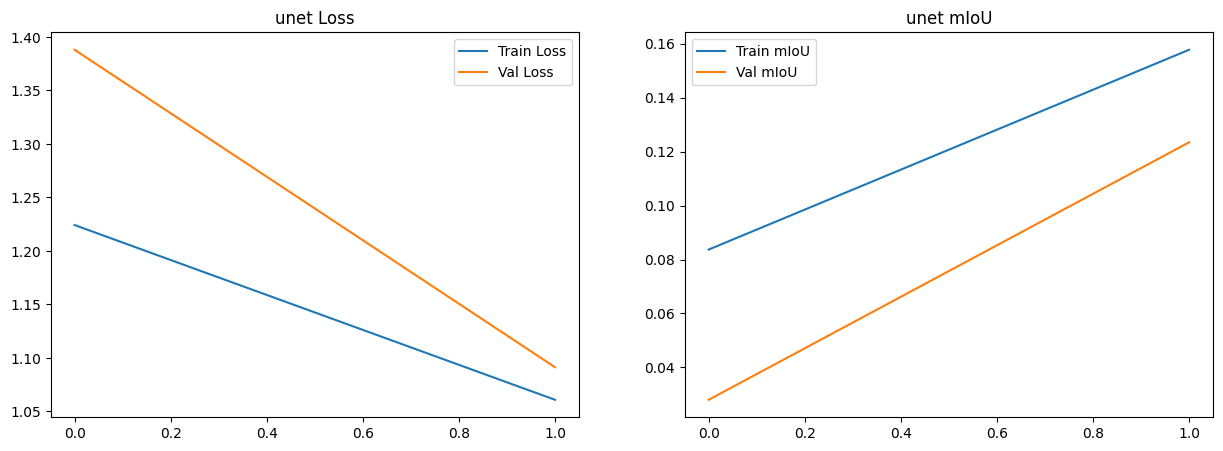

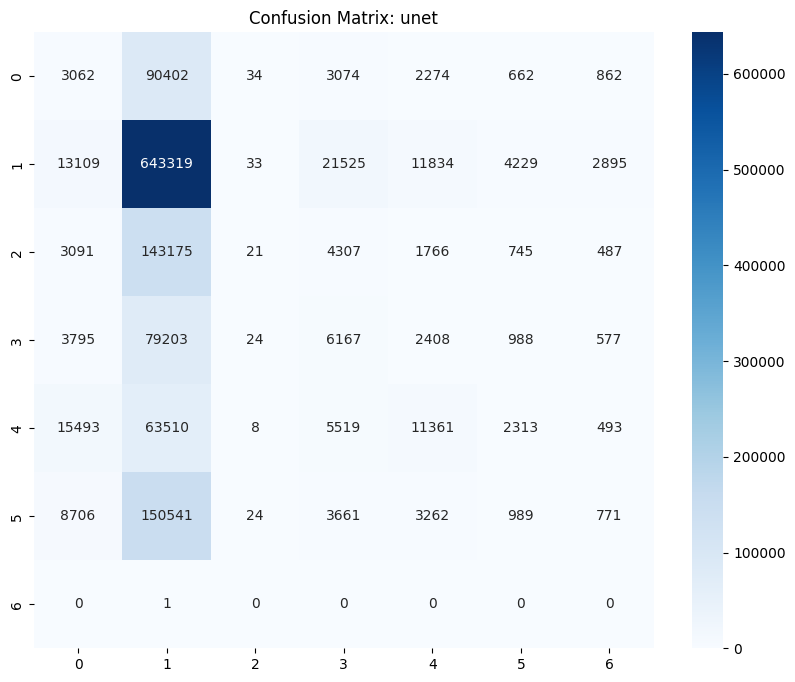

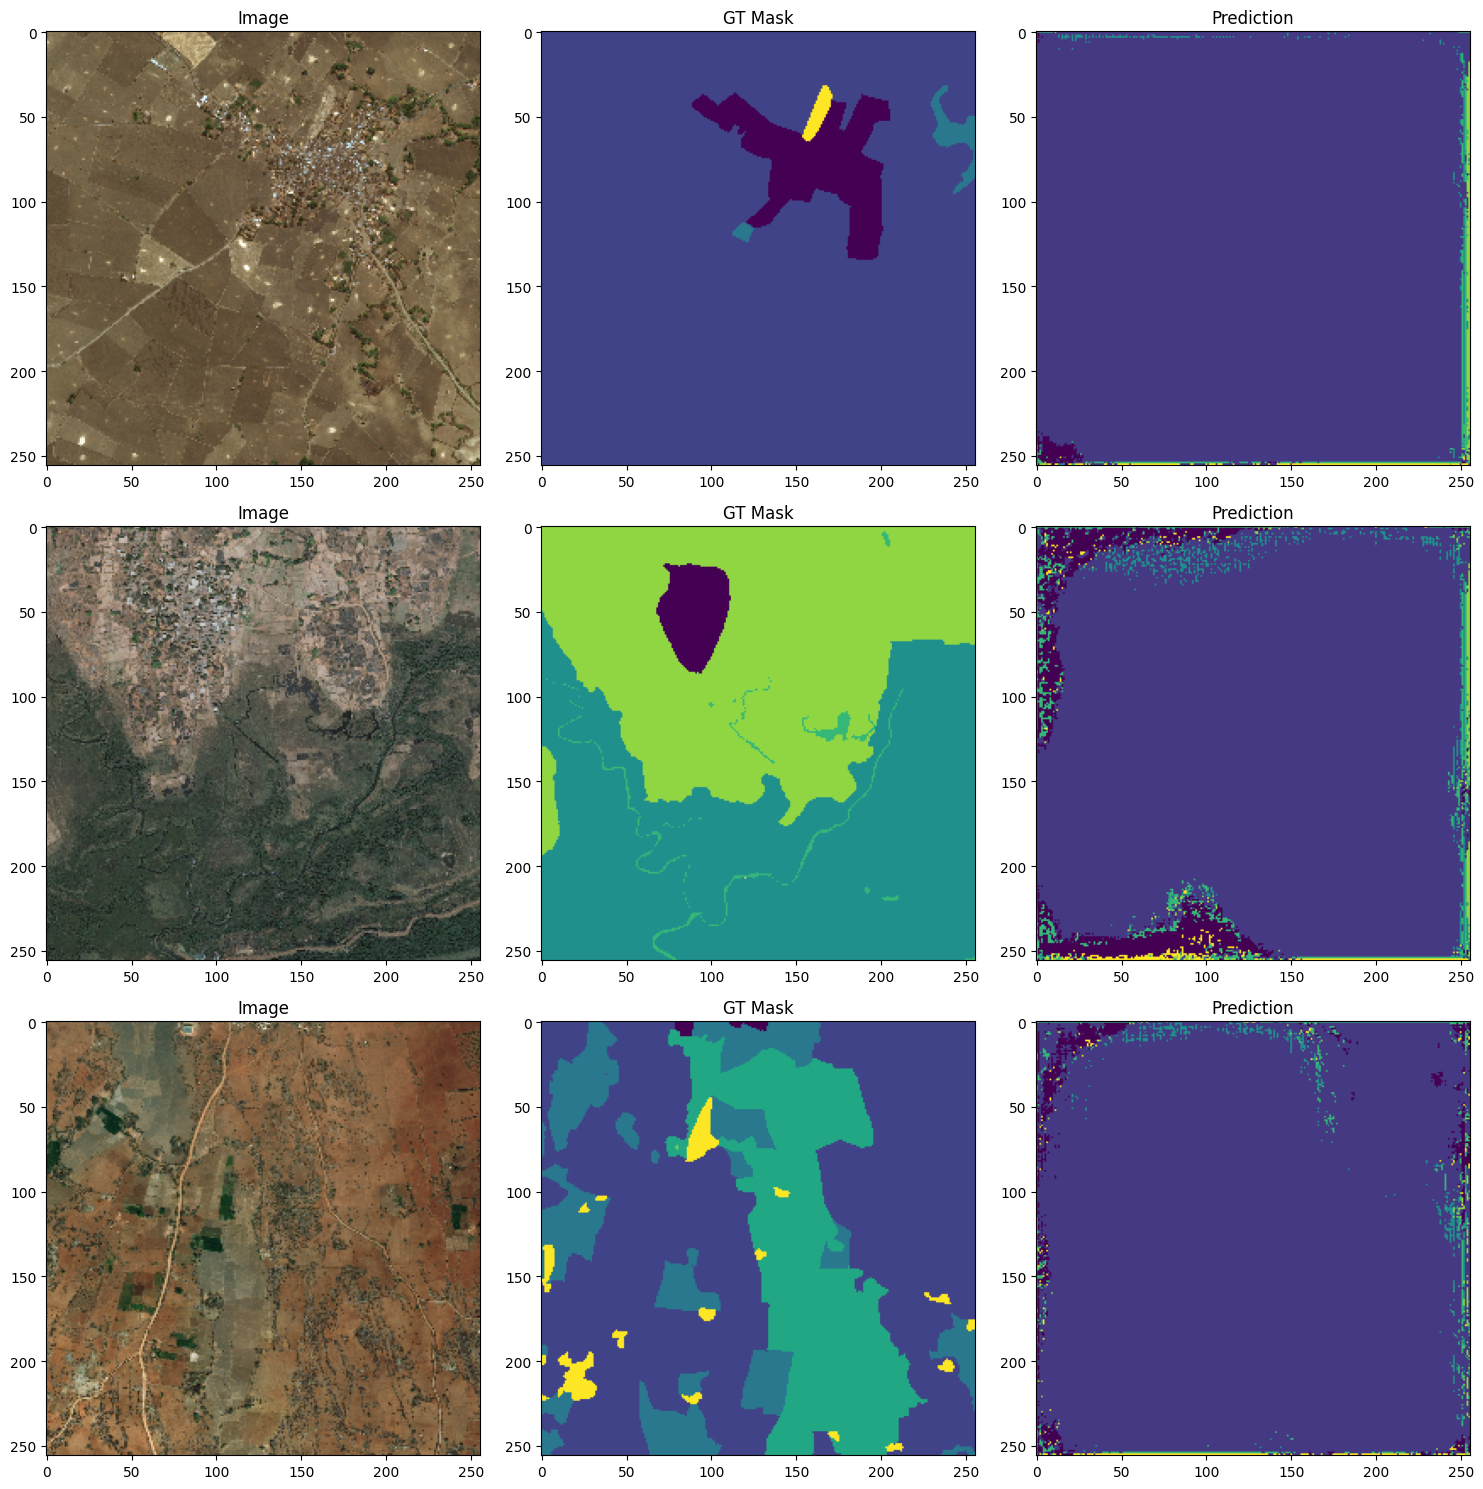


==================== Training deeplabv3plus ====================


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/2 | Train mIoU: 0.1135 | Val mIoU: 0.0053


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 2/2 | Train mIoU: 0.2223 | Val mIoU: 0.0209


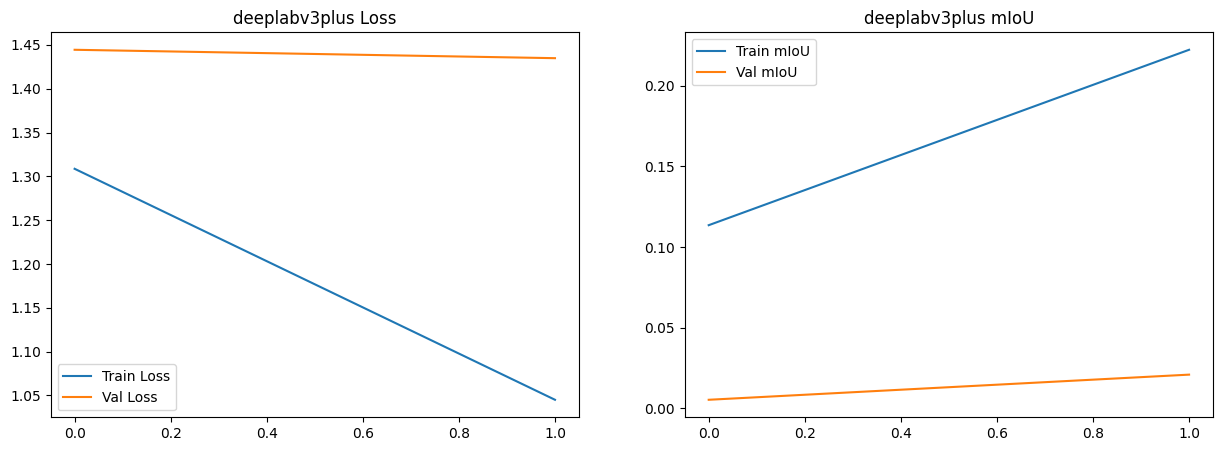

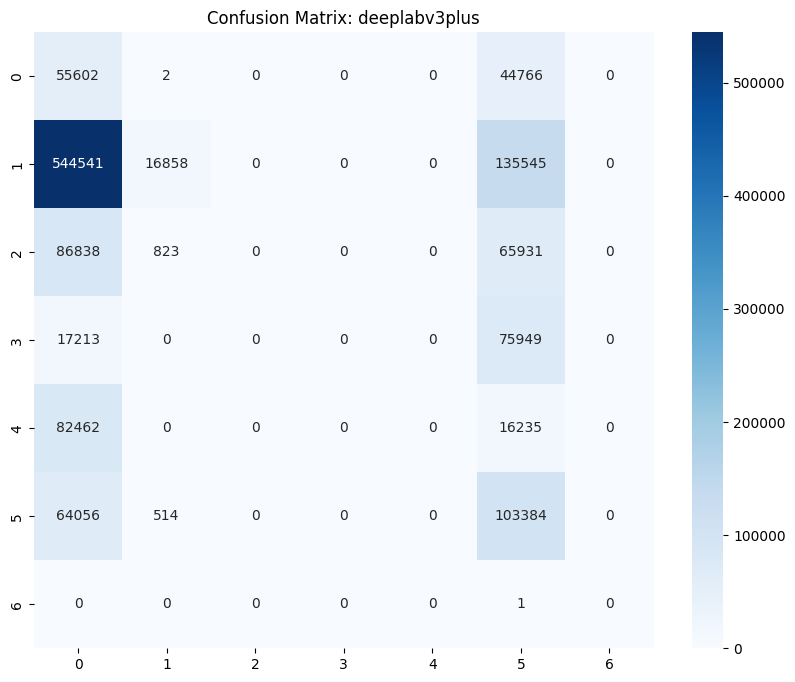

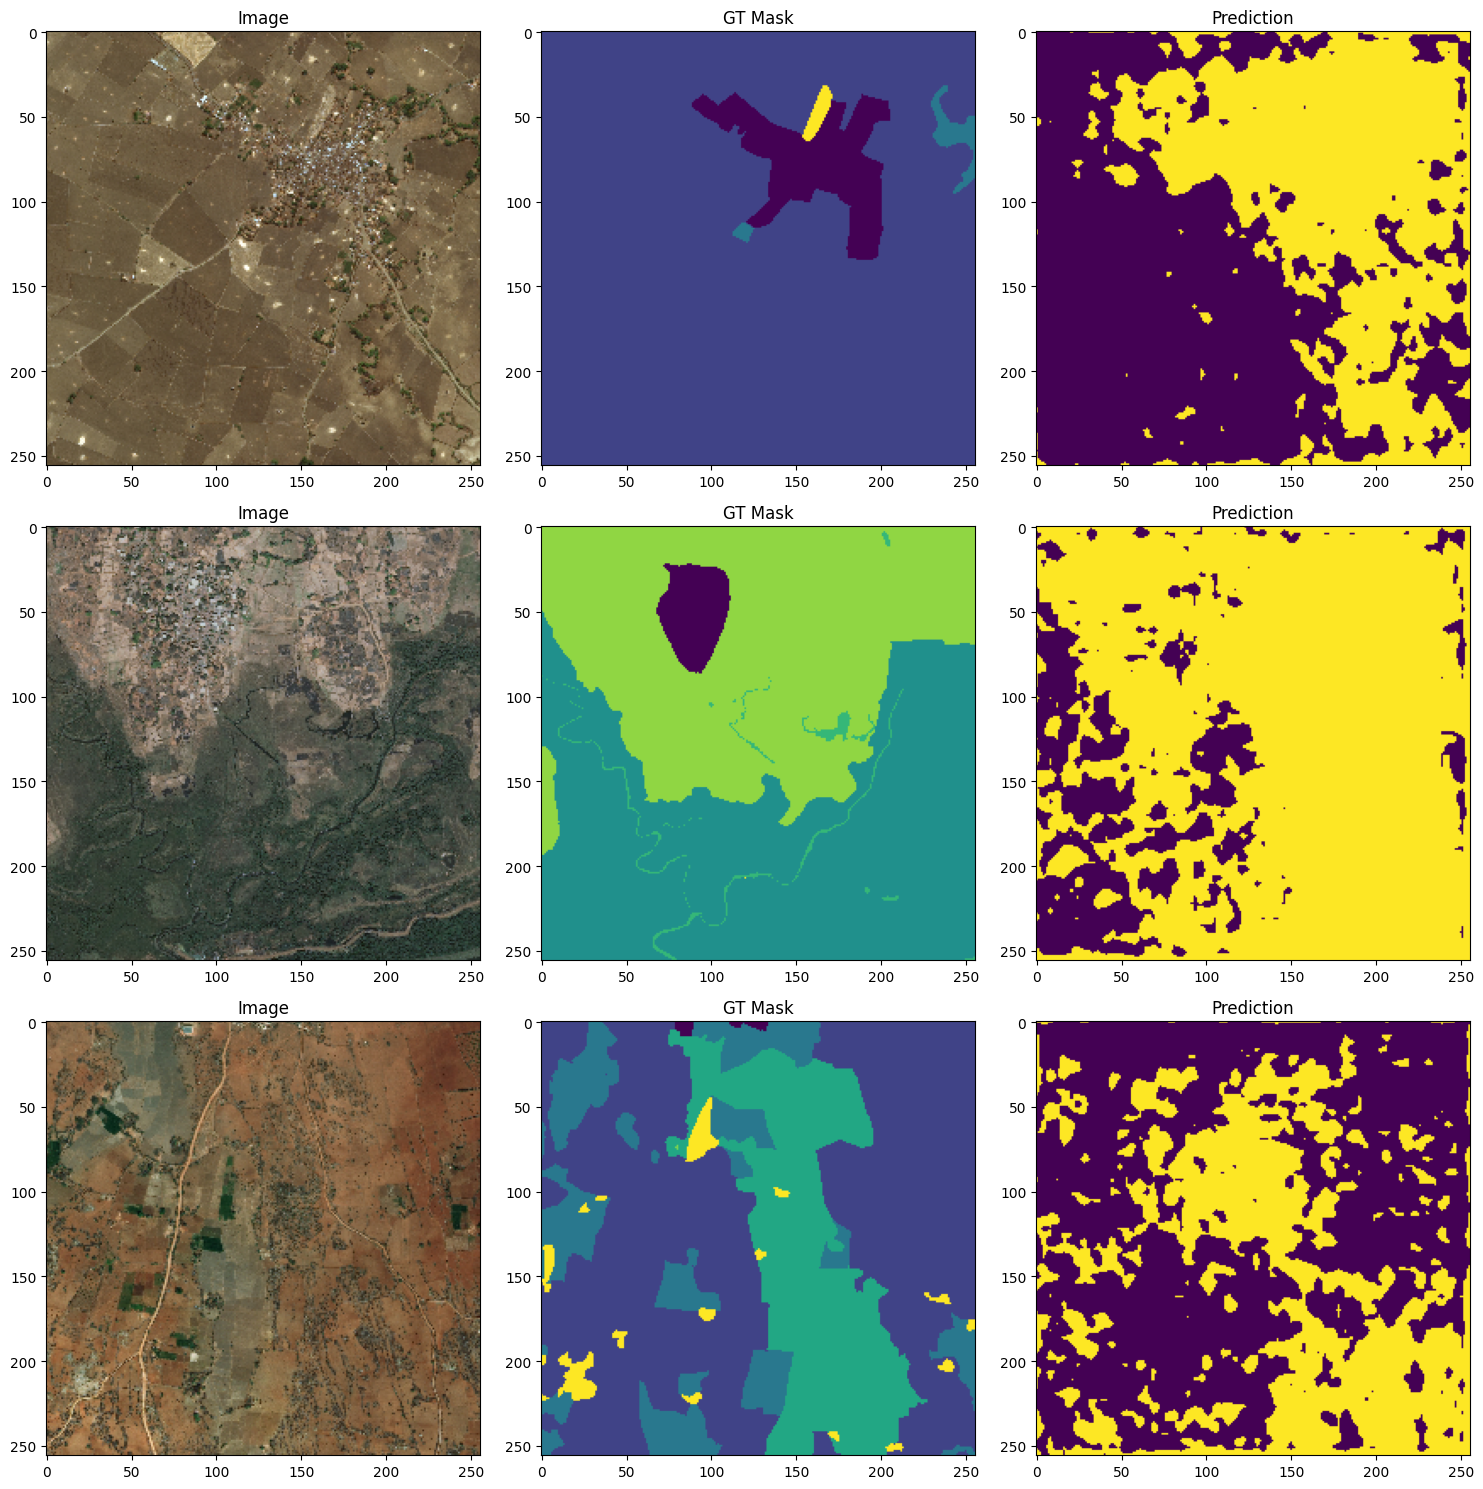


==================== Training segformer ====================


[transformers] You passed `num_labels=7` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.bias                                         | UNEXPECTED | 
classifier.weight                                       | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.classifier.bias                             

Training:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/2 | Train mIoU: 0.1611 | Val mIoU: 0.1177


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 2/2 | Train mIoU: 0.3850 | Val mIoU: 0.1363


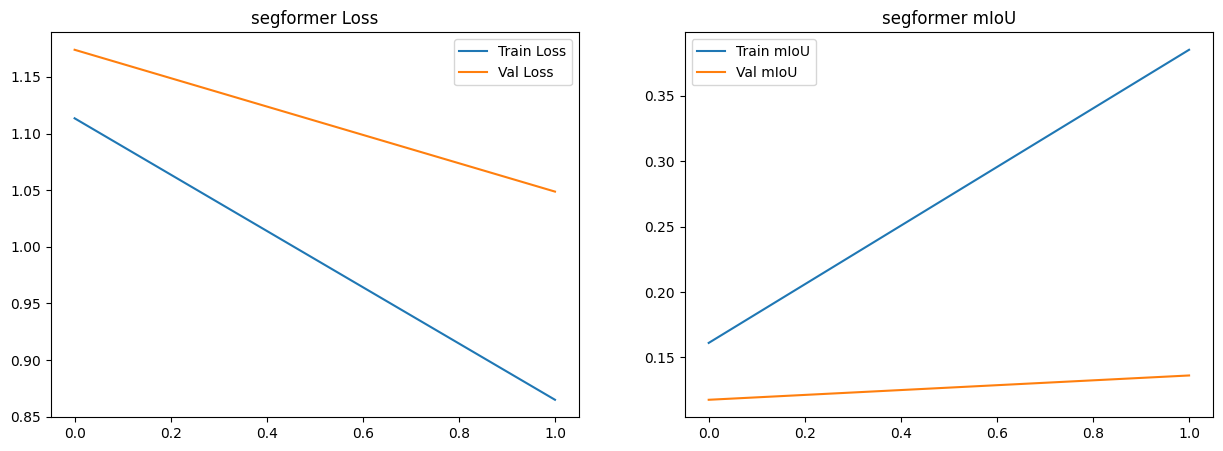

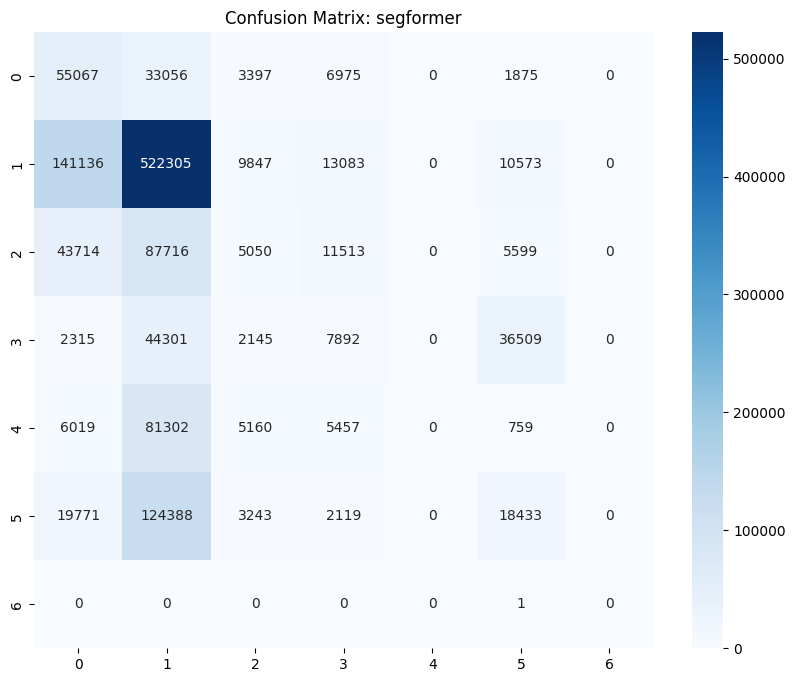

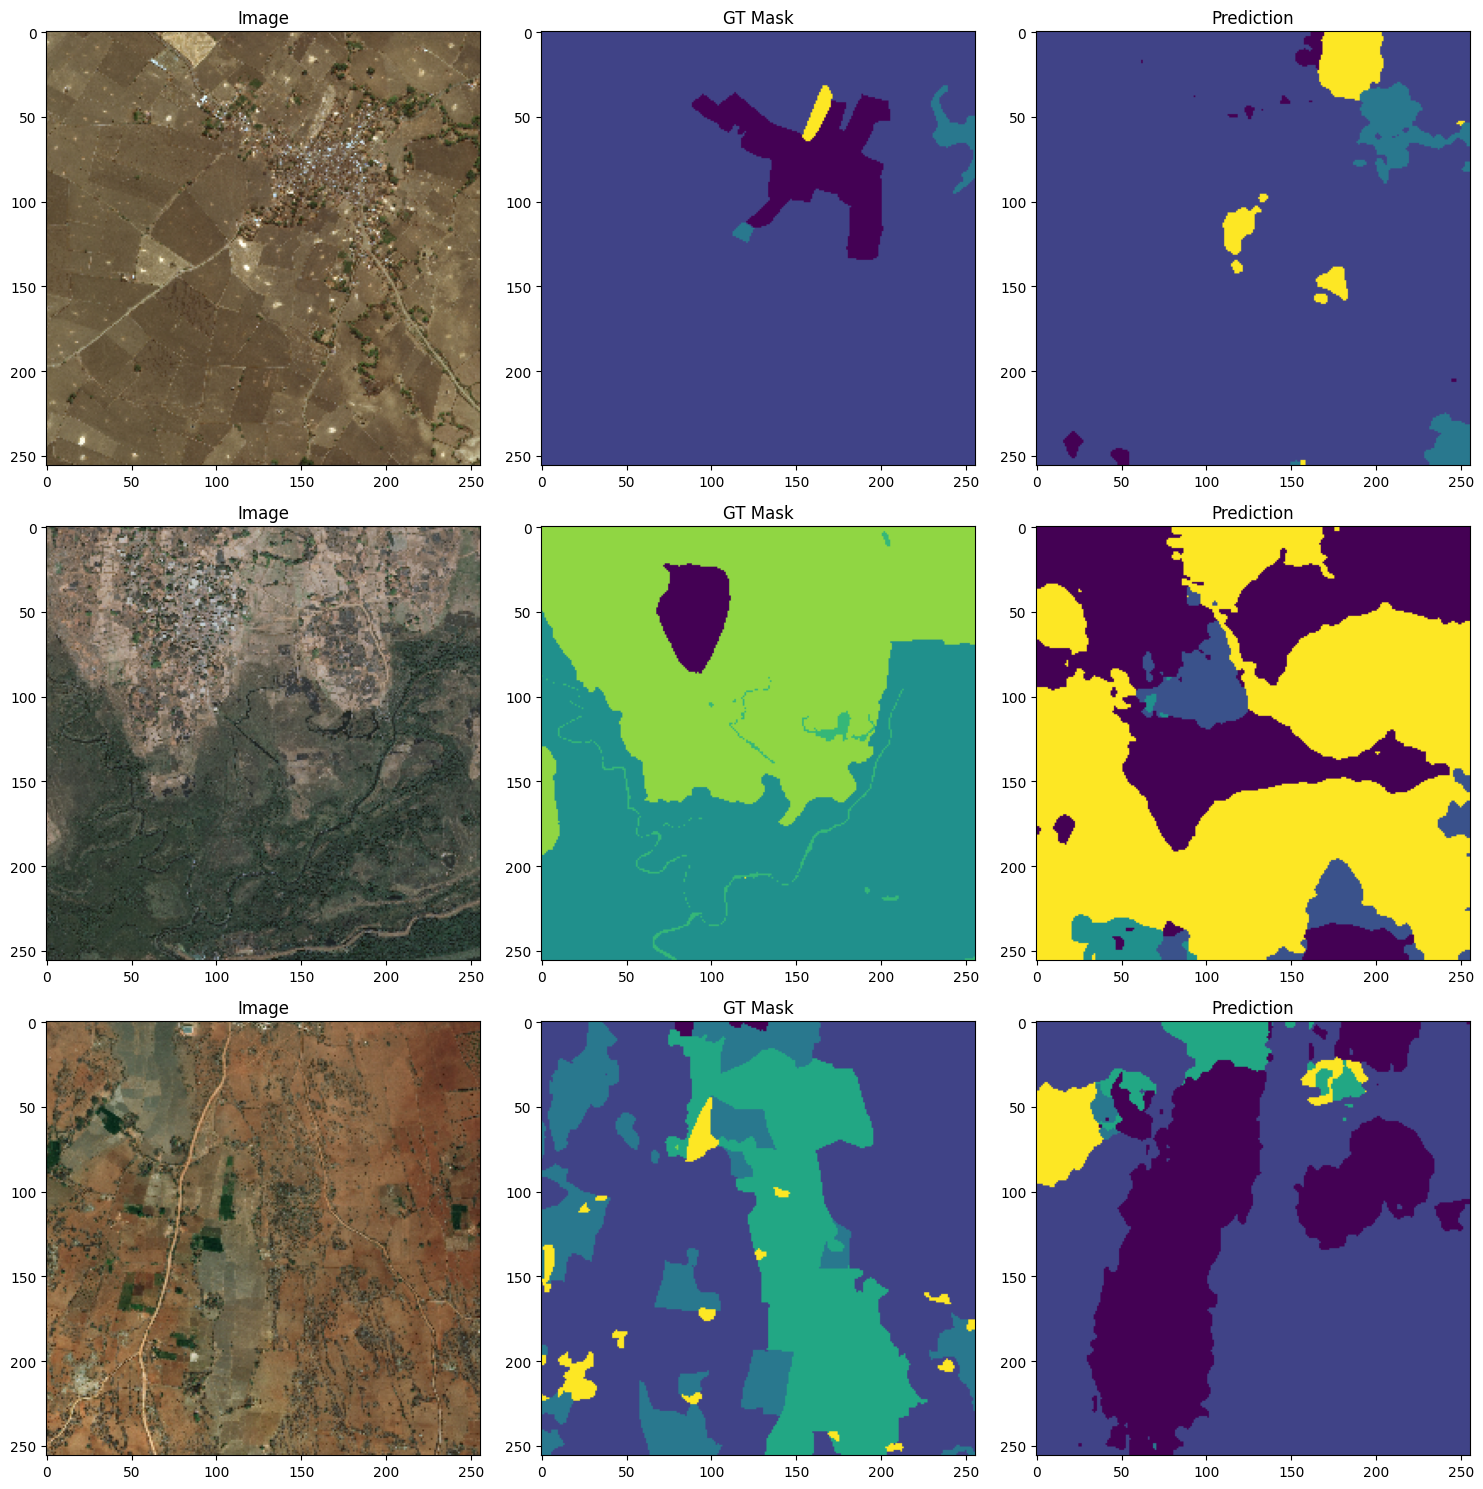


--- Final Model Comparison ---


,Model,Params,Train Time (s),Inf Time/Img (s),Best Val mIoU
0,unet,9013943,329.89,0.0016,0.1235
1,deeplabv3plus,3171095,297.53,0.0016,0.0209
2,segformer,3155719,303.41,0.1745,0.1363


In [24]:
import torch
import gc

def main():
    # Clear memory before starting
    gc.collect()
    torch.cuda.empty_cache()

    # 1. Initialize Datasets with Subsampling for speed
    # Limit to 50 train and 20 val samples for a quick run
    train_sub_df = train_df.sample(n=min(50, len(train_df)), random_state=42)
    val_sub_df = val_df.sample(n=min(20, len(val_df)), random_state=42)

    train_ds = DeepGlobeDataset(train_sub_df, transform=train_transform)
    val_ds = DeepGlobeDataset(val_sub_df, transform=val_transform)
    test_ds = DeepGlobeDataset(test_df.head(20), transform=val_transform)

    # 2. Initialize Loaders
    train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)

    models_to_compare = ["unet", "deeplabv3plus", "segformer"]
    global results_summary
    results_summary = []

    for m_name in models_to_compare:
        model, history, train_time = run_experiment(m_name, train_loader, val_loader)
        plot_history(history, m_name)
        inf_time = evaluate_model(model, test_loader, Config.DEVICE, m_name)
        visualize_predictions(model, test_loader, Config.DEVICE)

        results_summary.append({
            "Model": m_name,
            "Params": count_parameters(model),
            "Train Time (s)": round(train_time, 2),
            "Inf Time/Img (s)": round(inf_time, 4),
            "Best Val mIoU": round(max(history["val_iou"]), 4)
        })

    comparison_df = pd.DataFrame(results_summary)
    print("\n--- Final Model Comparison ---")
    display(comparison_df)

if __name__ == "__main__":
    main()